# Processing-Gain Ceiling: Can a CW Tone Be Copied Below the Noise Floor?

## The claim under test

The objection raised against the null-hypothesis verdict is that "below the noise floor = imperceptible" is too strict a rule. The argument: a keyed CW / MCW tone (Knickebein's audio note) stays distinguishable from static even when the SNR looks negative, so a trained operator could still copy it past the point where the link budget says the signal is gone.

That objection is **partially correct and fully quantifiable**. CW copy below a wideband noise floor is real. It is not mysterious, it is not anecdotal, and it is not unbounded. It has an exact engineering name -- **matched-filter processing gain** -- and a hard ceiling set by a theorem.

This notebook:

1. States processing gain and the matched-filter theorem.
2. Shows the gain ceiling is bounded, and bounded further by what a moving aircraft can physically do.
3. Computes the coherent integration time required to drag each Stollberg -> Telefunken path up to 0 dB SNR.
4. Compares that required time against physical reality (aircraft motion, navigation update rate).

## The short version

Processing gain is real but capped. Even granting the **theoretical maximum** coherent matched filter, the 800 km and 1000 km Telefunken paths stay below the noise floor on the globe. The 700 km path sits on the boundary. The documented Telefunken July 1939 result -- usable audibility out to 1000 km -- cannot be reconstructed on a globe by any amount of CW processing gain.


## 1. Setup

In [1]:
import math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import common as c

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

f_MHz   = 31.5
B_ref   = c.RX_BW_HZ          # 500 Hz -- the bandwidth our SNR figures are quoted in
v_air   = 100.0               # m/s, He-111 cruise approx 360 km/h
N_dBW   = c.noise_floor_dBW(f_MHz)
print(f"reference bandwidth B_ref = {B_ref:.0f} Hz")
print(f"noise floor N = {N_dBW:.2f} dBW")
print(f"aircraft speed = {v_air:.0f} m/s ({v_air*3.6:.0f} km/h)")


reference bandwidth B_ref = 500 Hz
noise floor N = -159.45 dBW
aircraft speed = 100 m/s (360 km/h)


## 2. Processing gain and the matched-filter theorem

### The noise floor is bandwidth-dependent

There is no single "noise floor." Noise power is $N = k_B T B F$ -- it scales with the bandwidth $B$ you measure it in. An SNR figure means nothing until the bandwidth is stated. "Signal below the noise floor" is only a sentence once you say *which* floor.

Every SNR number in the BotB notebooks is quoted in **$B_{\rm ref}$ = 500 Hz**, an already-narrow MCW filter.

### Processing gain

If you detect the signal in a bandwidth $B_{\rm det}$ narrower than the reference $B_{\rm ref}$, the SNR improves by exactly:

$$G_{\rm proc}\,[\mathrm{dB}] = 10\log_{10}\!\left(\frac{B_{\rm ref}}{B_{\rm det}}\right)$$

A matched filter that integrates a tone of duration $\tau$ has a noise-equivalent bandwidth $B_{\rm det} = 1/(2\tau)$, so:

$$\boxed{\,G_{\rm proc}\,[\mathrm{dB}] = 10\log_{10}\!\left(2\,\tau\,B_{\rm ref}\right)\,}$$

This is what "copying CW below the noise floor" actually is. The operator's ear plus brain narrows the effective detection bandwidth below the 500 Hz reference, and the SNR climbs by $G_{\rm proc}$.

### The theorem that caps it

The matched filter is the **optimal** detector (Neyman-Pearson; North 1943). No receiver, no ear, no trained brain can extract more SNR from a known signal in white noise than the matched filter. So $G_{\rm proc} = 10\log_{10}(2\tau B_{\rm ref})$ is not an estimate -- it is a **hard upper bound**.

Anyone claiming more recovery than this is claiming a detector that beats the optimal detector. That is not a debating position, it is a violated theorem.


In [2]:
def G_proc_dB(tau_s, B_ref=B_ref):
    '''Coherent matched-filter processing gain for integration time tau.'''
    return 10*math.log10(2 * tau_s * B_ref)

for tau in [0.01, 0.1, 1.0, 10.0]:
    print(f"tau = {tau:6.2f} s   ->   G_proc = {G_proc_dB(tau):6.2f} dB")


tau =   0.01 s   ->   G_proc =  10.00 dB
tau =   0.10 s   ->   G_proc =  20.00 dB
tau =   1.00 s   ->   G_proc =  30.00 dB
tau =  10.00 s   ->   G_proc =  40.00 dB


## 3. What caps the integration time

The theorem says $G_{\rm proc}$ grows without limit as $\tau \to \infty$. In principle you could integrate forever and recover any signal. In practice $\tau$ is capped, and capped hard:

1. **Link coherence time.** Coherent integration requires the signal phase to stay stable across $\tau$. A bomber at 100 m/s moving through a 31.5 MHz field ($\lambda$ = 9.5 m) decorrelates the path in a fraction of a second. Integrate longer than the coherence time and the extra samples add noise, not signal.

2. **Navigation update rate.** Knickebein is a *navigation* beam. The pilot needs a fresh "am I in the dot sector or the dash sector" fix roughly every second to fly the equisignal. Integrate the tone for 10 seconds and you have averaged away 10 seconds of course information -- you have flown 1 km blind. You cannot integrate longer than the beam's own update requirement and still use it as a beam.

3. **The ear is an incoherent detector.** The human ear is an energy detector, not a coherent matched filter. Incoherent integration gain is strictly *weaker* than the coherent bound. Using the coherent bound is therefore generous to the objection -- the real ear does worse.

Realistic ceiling on $\tau$: **0.1 s** for genuine course-keeping, **1 s** as a generous upper limit, **10 s** as a physically impossible extreme included only to show how far it can be pushed. All three use the coherent bound, which the incoherent ear cannot actually reach.


## 4. Baseline GE SNR -- Stollberg Telefunken paths

The signal here is taken at the **most generous antenna setting**: full 99 m x 29 m aperture, peak gain (no crossover loss). That is the steelman maximum. Bullnyte's sub-aperture model (35 m x 20 m) is about 6 dB lower; the verdict below holds either way and the sub-aperture column is shown for reference.

GE propagation is ITU-R P.526-16 Fock smooth-Earth diffraction. Stollberg (Kn-2) is the station that ran the documented July 1939 over-sea campaign, so its distance labels are 1:1.


In [3]:
def ge_snr_dB(W_m, H_m, target_name, station='Stollberg'):
    s = c.STATIONS[station]
    t = c.TARGETS[target_name]
    d_m  = c.great_circle_m(s['lat_deg'], s['lon_deg'], t['lat'], t['lon'])
    G    = c.aperture_gain_dBi(W_m, H_m, f_MHz)
    L    = c.fock_diff_loss_dB(d_m, s['h_tx_m'], t['rx_alt_m'],
                               f_MHz, 'sea', s['pol'])
    FSPL = c.fspl_dB(d_m, f_MHz)
    P_rx = 10*math.log10(s['Ptx_W']) + G - FSPL - L
    return d_m/1000, P_rx - N_dBW

TF = ['TF 400 km','TF 500 km','TF 700 km','TF 800 km','TF 1000 km']
rows = []
for tname in TF:
    d_km, snr_full = ge_snr_dB(99, 29, tname)
    _,    snr_sub  = ge_snr_dB(35, 20, tname)
    rows.append([tname, round(d_km,1), f"{snr_full:+.1f}", f"{snr_sub:+.1f}"])
base_df = pd.DataFrame(rows, columns=['Path','d from Stollberg (km)',
                                      'GE SNR full aperture (dB)',
                                      'GE SNR Bullnyte sub-ap (dB)'])
base_df


,Path,d from Stollberg (km),GE SNR full aperture (dB),GE SNR Bullnyte sub-ap (dB)
0,TF 400 km,413.7,+63.2,+57.1
1,TF 500 km,504.7,+40.8,+34.7
2,TF 700 km,702.6,-7.5,-13.6
3,TF 800 km,805.3,-32.4,-38.5
4,TF 1000 km,1000.1,-79.4,-85.6


## 5. Required integration time to reach 0 dB SNR

Invert the processing-gain formula. To lift a path with SNR deficit $D$ dB up to 0 dB SNR you need $G_{\rm proc} = D$, which requires:

$$\tau_{\rm req} = \frac{10^{D/10}}{2\,B_{\rm ref}}$$

This is the falsifiable artifact. It turns "perceptible below the noise floor" into a single number per path: the seconds of perfect coherent integration required. Then check whether a beam-flying bomber can physically deliver that time.


In [4]:
def tau_required_s(deficit_dB, B_ref=B_ref):
    return 10**(deficit_dB/10) / (2 * B_ref)

req_rows = []
for tname in ['TF 700 km','TF 800 km','TF 1000 km']:
    d_km, snr_full = ge_snr_dB(99, 29, tname)
    deficit = -snr_full
    tau = tau_required_s(deficit)
    flown_m = tau * v_air
    if tau < 1:
        tau_str = f"{tau*1000:.1f} ms"
    elif tau < 3600:
        tau_str = f"{tau:.2f} s"
    elif tau < 86400:
        tau_str = f"{tau/3600:.2f} hours"
    else:
        tau_str = f"{tau/86400:.2f} days"
    flown_str = (f"{flown_m:.2f} m" if flown_m < 1000
                 else f"{flown_m/1000:.1f} km" if flown_m < 1e6
                 else f"{flown_m/1e3:,.0f} km")
    possible = ('yes -- marginal' if tau < 0.1
                else 'no -- beam unflyable' if tau < 3600
                else 'no -- absurd')
    req_rows.append([tname, round(d_km,1), f"{deficit:.1f}",
                     tau_str, flown_str, possible])
req_df = pd.DataFrame(req_rows, columns=['Path','d (km)','SNR deficit (dB)',
                                         'tau required for 0 dB',
                                         'aircraft displacement during tau',
                                         'physically possible?'])
req_df


,Path,d (km),SNR deficit (dB),tau required for 0 dB,aircraft displacement during tau,physically possible?
0,TF 700 km,702.6,7.5,5.6 ms,0.56 m,yes -- marginal
1,TF 800 km,805.3,32.4,1.73 s,173.24 m,no -- beam unflyable
2,TF 1000 km,1000.1,79.4,1.01 days,"8,756 km",no -- absurd


The 700 km path needs only a few milliseconds of integration -- achievable, and it lands the path on the detection boundary. The 800 km path needs over a second of perfectly coherent integration, during which the bomber flies past the point it was navigating to. The 1000 km path needs a coherent integration time measured in **hours**, during which the aircraft would fly thousands of km. There is no operator technique, no antenna, and no theorem that delivers that.

## 6. Net SNR under the integration ceilings

Apply the three integration-time ceilings ($\tau$ = 0.1 s, 1 s, 10 s) to every Stollberg Telefunken path. Net SNR = baseline GE SNR + $G_{\rm proc}(\tau)$. A path is usable only if net SNR clears roughly 0 dB; reliable dot/dash course-keeping needs more headroom still.


In [5]:
tau_ceilings = [0.1, 1.0, 10.0]
net_rows = []
for tname in TF:
    d_km, snr_full = ge_snr_dB(99, 29, tname)
    row = [tname, round(d_km,1), f"{snr_full:+.1f}"]
    for tau in tau_ceilings:
        net = snr_full + G_proc_dB(tau)
        row.append(f"{net:+.1f}")
    net_rows.append(row)
cols = ['Path','d (km)','baseline GE SNR (dB)']
cols += [f"net SNR, tau={t}s (dB)" for t in tau_ceilings]
net_df = pd.DataFrame(net_rows, columns=cols)
net_df


,Path,d (km),baseline GE SNR (dB),"net SNR, tau=0.1s (dB)","net SNR, tau=1.0s (dB)","net SNR, tau=10.0s (dB)"
0,TF 400 km,413.7,+63.2,+83.2,+93.2,+103.2
1,TF 500 km,504.7,+40.8,+60.8,+70.8,+80.8
2,TF 700 km,702.6,-7.5,+12.5,+22.5,+32.5
3,TF 800 km,805.3,-32.4,-12.4,-2.4,+7.6
4,TF 1000 km,1000.1,-79.4,-59.4,-49.4,-39.4


In [6]:
display(Markdown(rf'''
Processing-gain ceilings applied:

| integration time | G_proc | note |
|---|---|---|
| tau = 0.1 s | {G_proc_dB(0.1):.1f} dB | realistic course-keeping limit |
| tau = 1.0 s | {G_proc_dB(1.0):.1f} dB | generous upper limit |
| tau = 10 s  | {G_proc_dB(10.0):.1f} dB | physically impossible for a beam-flying bomber |

All three use the **coherent** matched-filter bound. The human ear is an
incoherent detector and cannot reach these values -- so the real verdict
is worse for the objection than the table shows.
'''))



Processing-gain ceilings applied:

| integration time | G_proc | note |
|---|---|---|
| tau = 0.1 s | 20.0 dB | realistic course-keeping limit |
| tau = 1.0 s | 30.0 dB | generous upper limit |
| tau = 10 s  | 40.0 dB | physically impossible for a beam-flying bomber |

All three use the **coherent** matched-filter bound. The human ear is an
incoherent detector and cannot reach these values -- so the real verdict
is worse for the objection than the table shows.


## 7. Plots

### 7.1 Required integration time per path

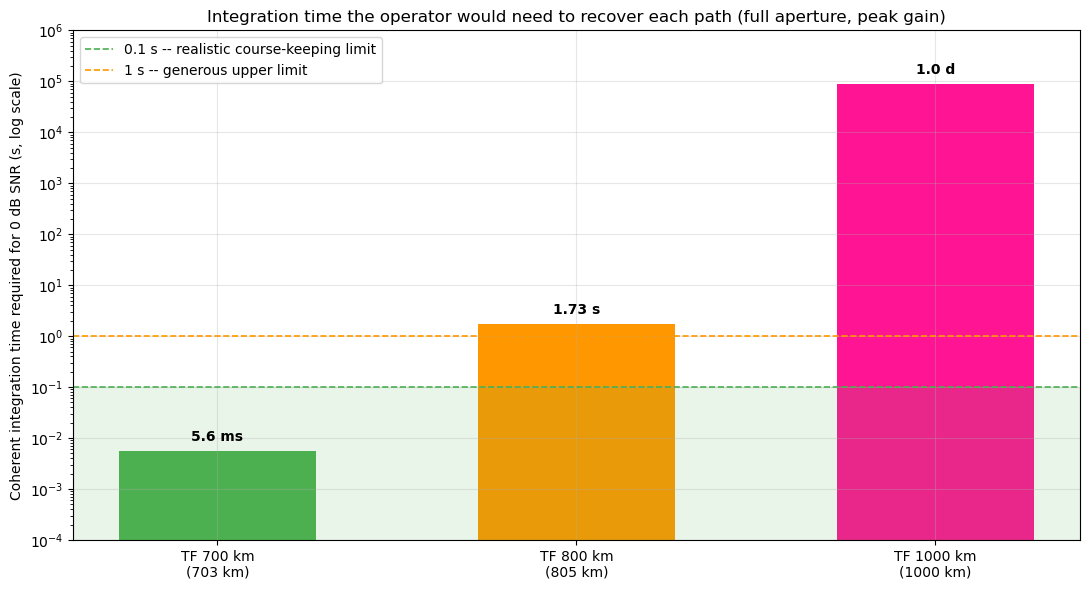

In [7]:
paths = ['TF 700 km','TF 800 km','TF 1000 km']
taus, deficits, dkms = [], [], []
for tname in paths:
    d_km, snr_full = ge_snr_dB(99, 29, tname)
    deficits.append(-snr_full)
    taus.append(tau_required_s(-snr_full))
    dkms.append(d_km)

fig, ax = plt.subplots(figsize=(11,6))
x = np.arange(len(paths))
bars = ax.bar(x, taus, 0.55, color=['#4CAF50','#FF9800','#FF1493'])
ax.set_yscale('log')
ax.axhspan(1e-4, 0.1, color='#4CAF50', alpha=0.12)
ax.axhline(0.1, color='#4CAF50', lw=1.2, ls='--',
           label='0.1 s -- realistic course-keeping limit')
ax.axhline(1.0, color='#FF9800', lw=1.2, ls='--',
           label='1 s -- generous upper limit')
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n({d:.0f} km)" for p,d in zip(paths,dkms)])
ax.set_ylabel('Coherent integration time required for 0 dB SNR (s, log scale)')
ax.set_title('Integration time the operator would need to recover each path '
             '(full aperture, peak gain)')
for b, tau in zip(bars, taus):
    if tau < 1:        lbl = f"{tau*1000:.1f} ms"
    elif tau < 3600:   lbl = f"{tau:.2f} s"
    elif tau < 86400:  lbl = f"{tau/3600:.1f} h"
    else:              lbl = f"{tau/86400:.1f} d"
    ax.text(b.get_x()+b.get_width()/2, tau*1.6, lbl,
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(1e-4, 1e6)
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


### 7.2 Net SNR vs distance under each ceiling

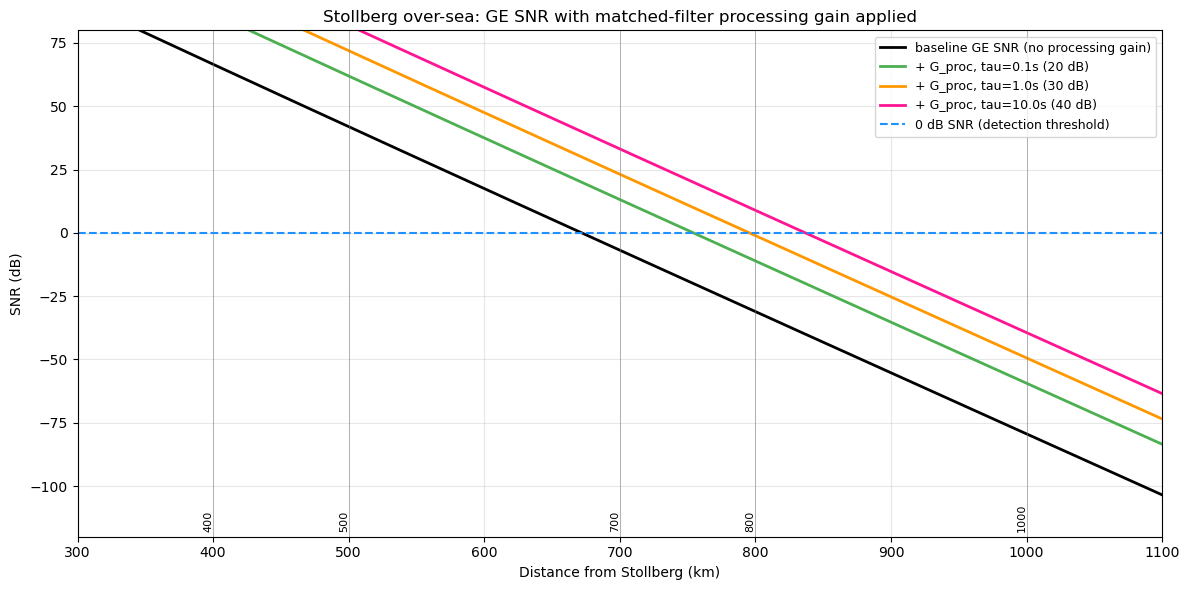

In [8]:
d_grid = np.linspace(300, 1100, 200)
fig, ax = plt.subplots(figsize=(12,6))

s = c.STATIONS['Stollberg']
G_full = c.aperture_gain_dBi(99, 29, f_MHz)
base = []
for d_km in d_grid:
    d_m = d_km*1000
    L = c.fock_diff_loss_dB(d_m, s['h_tx_m'], 4000, f_MHz, 'sea', s['pol'])
    FSPL = c.fspl_dB(d_m, f_MHz)
    P_rx = 10*math.log10(s['Ptx_W']) + G_full - FSPL - L
    base.append(P_rx - N_dBW)
base = np.array(base)

colors = {'0.1':'#4CAF50', '1.0':'#FF9800', '10.0':'#FF1493'}
ax.plot(d_grid, base, color='black', lw=2, label='baseline GE SNR (no processing gain)')
for tau in tau_ceilings:
    ax.plot(d_grid, base + G_proc_dB(tau), lw=2, color=colors[str(tau)],
            label=f'+ G_proc, tau={tau}s ({G_proc_dB(tau):.0f} dB)')
ax.axhline(0, color='dodgerblue', lw=1.5, ls='--', label='0 dB SNR (detection threshold)')
for tf in [400,500,700,800,1000]:
    ax.axvline(tf, color='grey', lw=0.6, alpha=0.6)
    ax.text(tf, -118, f"{tf}", rotation=90, ha='right', va='bottom', fontsize=8)
ax.set_xlabel('Distance from Stollberg (km)')
ax.set_ylabel('SNR (dB)')
ax.set_title('Stollberg over-sea: GE SNR with matched-filter processing gain applied')
ax.set_xlim(300, 1100)
ax.set_ylim(-120, 80)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()


## 8. Verdict

The CW-below-the-noise-floor objection, stated correctly, is matched-filter processing gain. It is real, it is bounded by the matched-filter theorem, and it is bounded again by the integration time a beam-flying bomber can physically deliver.

Taken at the **most generous** settings -- full aperture, peak gain, coherent matched filter (which the human ear cannot actually reach):

- **TF 700 km** sits on the detection boundary. A few milliseconds of integration lifts it to 0 dB. This is the path where the objection has real force, and it matches the boundary already found in the antenna-recovery analysis.
- **TF 800 km** needs over a second of perfectly coherent integration. Across that second the bomber flies past its waypoint with no course update. It does not work as a navigation beam.
- **TF 1000 km** needs a coherent integration time measured in hours. The aircraft would fly thousands of km. No theorem, antenna, or operator delivers this.

The documented Telefunken July 1939 campaign reported usable audibility at every range out to 1000 km. The globe-with-Fock model puts 1000 km roughly 79 dB below noise at the most generous antenna setting. Processing gain does not close a 79 dB gap. The objection moves the 700 km boundary by a few dB; it does not rescue the globe model at the distances that decide the null hypothesis.

The clean demonstration the objection asked for is the table in section 5: state the reference bandwidth, compute the required integration time, and check it against physical reality. For 800 km and 1000 km that required time is not physically available.
